In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [2]:

# =======================================================================
# CONFIGURAÇÕES
# =======================================================================

DIMENSOES = ["fluency", "coherence", "consistency", "relevance"]
LABELS_DIMENSOES = ["Fluency", "Coherence", "Consistency", "Relevance"]

CAMINHOS_HUMAN = {
    "QMSum Baseline": "./data/qmsum/qmsum_baseline_evaluate.csv",
    "QMSum FT": "./data/qmsum/qmsum_ft_evaluate.csv",
    "Hier. Base": "./hierarq_data/hierarquico/human/hier_base_evaluate_human.csv",
    "Hier. SAMSum FT": "./hierarq_data/hierarquico/human/hier_samsum_evaluate_human.csv",
    "Hier. MediaSum FT": "./hierarq_data/hierarquico/human/hier_mediasum_evaluate_human.csv",
    "Hier. SAMSum+QMSum FT": "./hierarq_data/hierarquico/human/hier_samsum_qmsumft_evaluate_human.csv",
}

CAMINHOS_GEVAL = {
    "QMSum Baseline": "./data/qmsum/qmsum_baseline_evaluate_geval.csv",
    "QMSum FT": "./data/qmsum/qmsum_ft_evaluate_geval.csv",
    "Hier. Base": "./hierarq_data/hierarquico/geval/hier_base_evaluate_geval.csv",
    "Hier. SAMSum FT": "./hierarq_data/hierarquico/geval/hier_samsum_evaluate_geval.csv",
    "Hier. MediaSum FT": "./hierarq_data/hierarquico/geval/hier_mediasum_evaluate_geval.csv",
    "Hier. SAMSum+QMSum FT": "./hierarq_data/hierarquico/geval/hier_samsum_qmsumft_evaluate_geval.csv",
}

OUTPUT_DIR = "./hierarq_data/hierarquico/analise"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CORES = ["#888780", "#378ADD", "#E8593C", "#1D9E75", "#7F77DD", "#D4537E"]


In [3]:

# =======================================================================
# CARREGAMENTO
# =======================================================================

def carregar_csv(caminho, sep=","):
    return pd.read_csv(caminho, sep=sep, engine="python",
                       quotechar='"', on_bad_lines="skip")

def get_sep(nome, caminho):
    # Os dois originais do QMSum usam ";"
    if "qmsum_baseline_evaluate" in caminho or "qmsum_ft_evaluate" in caminho:
        if "geval" not in caminho:
            return ";"
    return ","

dfs_human = {}
for nome, caminho in CAMINHOS_HUMAN.items():
    sep = get_sep(nome, caminho)
    dfs_human[nome] = carregar_csv(caminho, sep=sep)
    print(f"  {nome} (human): {len(dfs_human[nome])} linhas")

dfs_geval = {}
for nome, caminho in CAMINHOS_GEVAL.items():
    dfs_geval[nome] = carregar_csv(caminho, sep=",")
    print(f"  {nome} (geval): {len(dfs_geval[nome])} linhas")


  QMSum Baseline (human): 8728 linhas
  QMSum FT (human): 8728 linhas
  Hier. Base (human): 40 linhas
  Hier. SAMSum FT (human): 40 linhas
  Hier. MediaSum FT (human): 40 linhas
  Hier. SAMSum+QMSum FT (human): 40 linhas
  QMSum Baseline (geval): 40 linhas
  QMSum FT (geval): 40 linhas
  Hier. Base (geval): 40 linhas
  Hier. SAMSum FT (geval): 40 linhas
  Hier. MediaSum FT (geval): 40 linhas
  Hier. SAMSum+QMSum FT (geval): 40 linhas


In [4]:

# =======================================================================
# EXTRAÇÃO DE VALORES E MÉDIAS
# =======================================================================

def extrair_valores(df, prefixo):
    valores = []
    for dim in DIMENSOES:
        col = f"{prefixo}{dim}"
        if col in df.columns:
            vals = df[col].dropna().astype(float).tolist()
        else:
            vals = []
        valores.append(vals)
    return valores

def extrair_medias(df, prefixo):
    return [
        df[f"{prefixo}{dim}"].dropna().astype(float).mean()
        if f"{prefixo}{dim}" in df.columns else np.nan
        for dim in DIMENSOES
    ]


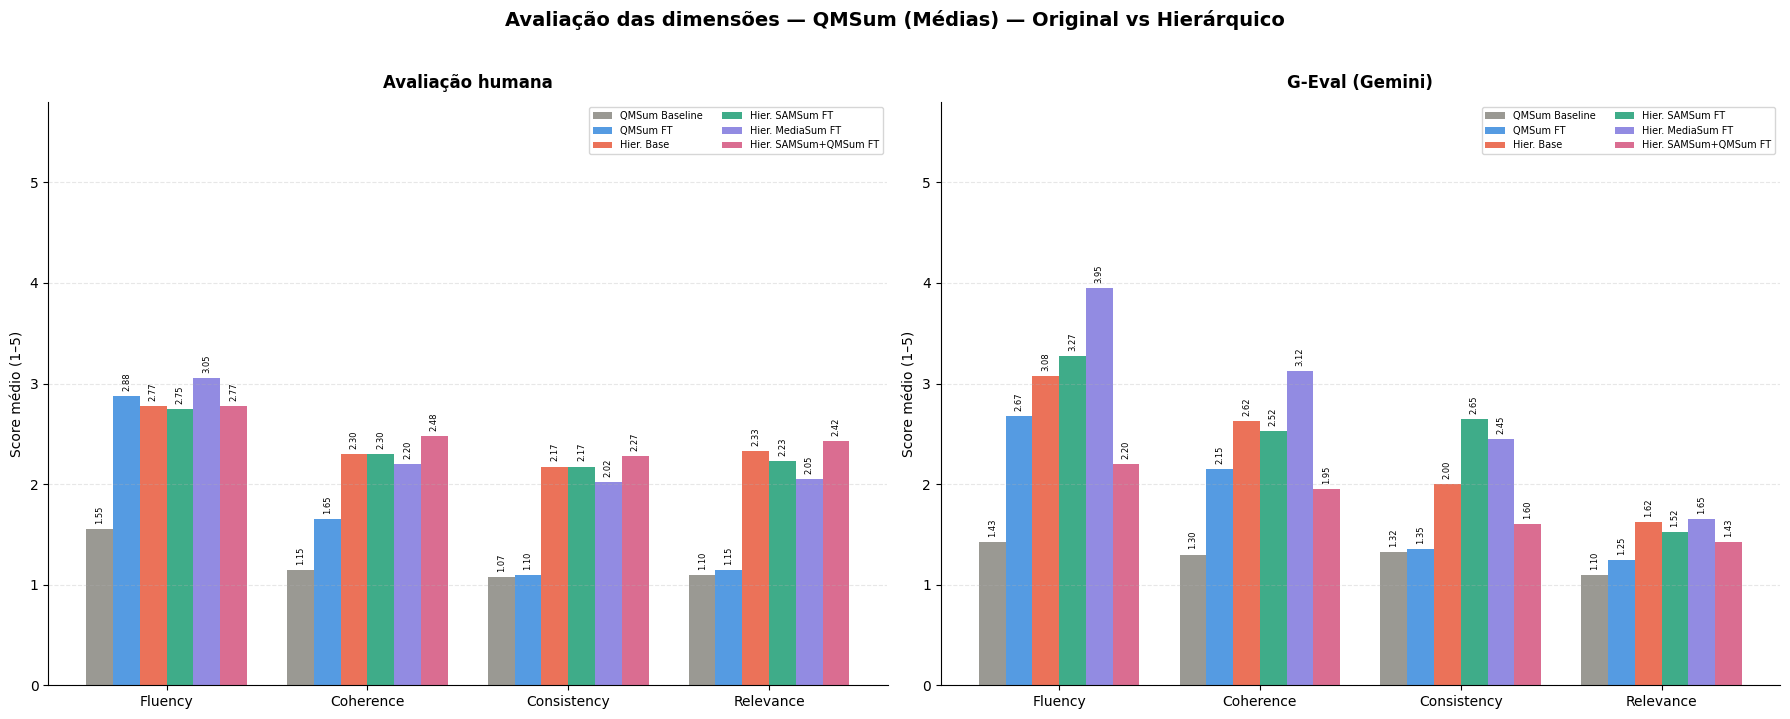

Gráfico de barras salvo!


In [5]:

# =======================================================================
# GRÁFICO DE BARRAS (MÉDIAS) — 6 VARIANTES
# =======================================================================

def plotar_barras_multivariante(ax, medias_dict, titulo):
    variantes = list(medias_dict.keys())
    x = np.arange(len(LABELS_DIMENSOES))
    width = 0.8 / len(variantes)

    for i, variante in enumerate(variantes):
        valores = medias_dict[variante]
        offset = (i - len(variantes)/2) * width + width/2
        bars = ax.bar(x + offset, valores, width, label=variante,
                      color=CORES[i % len(CORES)], alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
                        f"{h:.2f}", ha="center", va="bottom",
                        fontsize=6, rotation=90)

    ax.set_title(titulo, fontsize=12, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS_DIMENSOES, fontsize=10)
    ax.set_ylim(0, 5.8)
    ax.set_ylabel("Score médio (1–5)", fontsize=10)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

medias_human = {nome: extrair_medias(df, "human_") for nome, df in dfs_human.items()}
medias_geval = {nome: extrair_medias(df, "geval_") for nome, df in dfs_geval.items()}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Avaliação das dimensões — QMSum (Médias) — Original vs Hierárquico",
             fontsize=14, fontweight="bold", y=1.02)

plotar_barras_multivariante(axes[0], medias_human, "Avaliação humana")
plotar_barras_multivariante(axes[1], medias_geval, "G-Eval (Gemini)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grafico_barras_qmsum_hierarquico.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUTPUT_DIR, "grafico_barras_qmsum_hierarquico.pdf"), bbox_inches="tight")
plt.show()
plt.close()
print("Gráfico de barras salvo!")


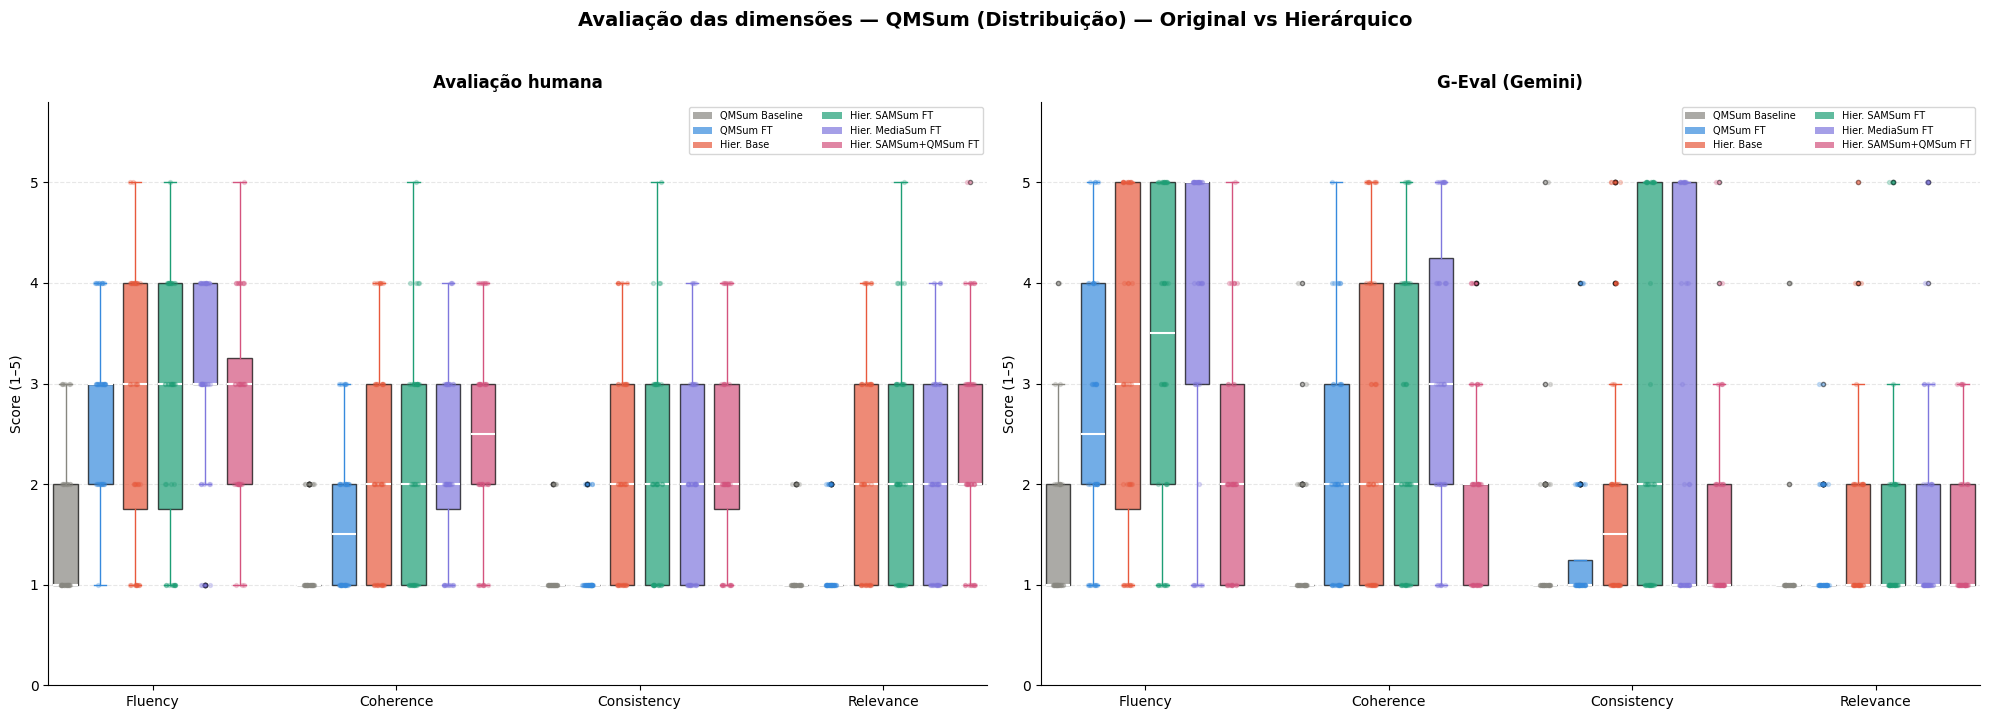

Boxplot salvo!


In [6]:

# =======================================================================
# BOXPLOT (DISTRIBUIÇÃO) — 6 VARIANTES
# =======================================================================

def plotar_boxplot_multivariante(ax, valores_dict, titulo):
    variantes = list(valores_dict.keys())
    n_dim = len(LABELS_DIMENSOES)
    n_var = len(variantes)

    largura_grupo = n_var + 1
    posicoes_base = np.arange(n_dim) * largura_grupo

    for i, variante in enumerate(variantes):
        valores = valores_dict[variante]
        posicoes = posicoes_base + i

        bp = ax.boxplot(valores, positions=posicoes, widths=0.7,
                        patch_artist=True, notch=False,
                        boxprops=dict(facecolor=CORES[i % len(CORES)], alpha=0.7),
                        medianprops=dict(color="white", linewidth=1.5),
                        whiskerprops=dict(color=CORES[i % len(CORES)]),
                        capprops=dict(color=CORES[i % len(CORES)]),
                        flierprops=dict(marker="o", color=CORES[i % len(CORES)],
                                        markerfacecolor=CORES[i % len(CORES)],
                                        markersize=3, alpha=0.5))

        for j, vals in enumerate(valores):
            if len(vals) == 0:
                continue
            jitter = np.random.uniform(-0.15, 0.15, size=len(vals))
            ax.scatter(posicoes[j] + jitter, vals,
                      color=CORES[i % len(CORES)], alpha=0.25, s=8, zorder=3)

    ticks_pos = posicoes_base + (n_var - 1) / 2
    ax.set_xticks(ticks_pos)
    ax.set_xticklabels(LABELS_DIMENSOES, fontsize=10)
    ax.set_ylim(0, 5.8)
    ax.set_ylabel("Score (1–5)", fontsize=10)
    ax.set_title(titulo, fontsize=12, fontweight="bold", pad=10)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor=CORES[i % len(CORES)], alpha=0.7, label=v)
        for i, v in enumerate(variantes)
    ], fontsize=7, ncol=2)

valores_human = {nome: extrair_valores(df, "human_") for nome, df in dfs_human.items()}
valores_geval = {nome: extrair_valores(df, "geval_") for nome, df in dfs_geval.items()}

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Avaliação das dimensões — QMSum (Distribuição) — Original vs Hierárquico",
             fontsize=14, fontweight="bold", y=1.02)

plotar_boxplot_multivariante(axes[0], valores_human, "Avaliação humana")
plotar_boxplot_multivariante(axes[1], valores_geval, "G-Eval (Gemini)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grafico_boxplot_qmsum_hierarquico.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUTPUT_DIR, "grafico_boxplot_qmsum_hierarquico.pdf"), bbox_inches="tight")
plt.show()
plt.close()
print("Boxplot salvo!")